# 은행 연체율(NPL) 예측 프로젝트 — ML 모델링

**예측 목표:** 현재 분기 거시경제 지표 → **다음 분기** NPL비율 예측  
**사용 피처:** 거시경제 지표만 (base_rate, deposit_rate, loan_rate, unemployment_rate, household_loan_balance)  
**Train/Test:** 2011Q4~2022Q4 (45개) / 2023Q1~2025Q3 (11개, 80/20)  

**비교 모델:**
1. Linear Regression (기준선)
2. Ridge Regression
3. Lasso Regression
4. Random Forest
5. XGBoost
6. LightGBM

In [1]:
# ──────────────────────────────────────────
# 0. 라이브러리 임포트
# ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model    import LinearRegression, Ridge, Lasso
from sklearn.ensemble        import RandomForestRegressor
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import mean_squared_error, mean_absolute_error, r2_score
from xgboost                 import XGBRegressor
from lightgbm                import LGBMRegressor

# 한글 폰트
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

print('라이브러리 로드 완료')

라이브러리 로드 완료


In [2]:
# ──────────────────────────────────────────
# 1. 데이터 로드 및 피처 엔지니어링
# ──────────────────────────────────────────
df = pd.read_csv('../data/processed/dataset.csv')
df['time_idx'] = range(len(df))

# 거시경제 지표 컬럼 (학습에 사용할 원본 변수)
macro_cols = ['base_rate', 'deposit_rate', 'loan_rate',
              'unemployment_rate', 'household_loan_balance']

# ── 피처 엔지니어링 ──────────────────────────
# (1) Lag 1 피처: 1분기 전 값 → 금리 변화가 NPL에 시차를 두고 영향
for col in macro_cols:
    df[f'{col}_lag1'] = df[col].shift(1)

# (2) 차분(diff) 피처: 전 분기 대비 변화량 → 방향성 정보
for col in macro_cols:
    df[f'{col}_diff1'] = df[col].diff(1)

# ── 예측 타겟 생성 ──────────────────────────
# 현재 분기 피처 → 다음 분기 NPL 예측
# shift(-1): 현재 행의 target = 다음 행의 NPL비율
df['target_npl'] = df['NPL비율'].shift(-1)

# Lag/Diff 계산에 쓴 첫 행(NaN)과 마지막 행(target 없음) 제거
df_model = df.dropna().reset_index(drop=True)

print(f'모델링 데이터 크기: {df_model.shape}')
print(f'기간: {df_model["quarter"].iloc[0]} ~ {df_model["quarter"].iloc[-1]}')
print(f'→ 각 행의 quarter = 입력 분기 / target_npl = 다음 분기 NPL')

모델링 데이터 크기: (55, 22)
기간: 2012Q1 ~ 2025Q3
→ 각 행의 quarter = 입력 분기 / target_npl = 다음 분기 NPL


In [3]:
# ──────────────────────────────────────────
# 2. Train / Test 분할 (시계열 기준, 미래 데이터 누수 방지)
# ──────────────────────────────────────────
# 사용할 최종 피처 목록
feature_cols = (
    macro_cols                                  # 현재 분기 거시지표
    + [f'{c}_lag1'  for c in macro_cols]        # 1분기 전 거시지표
    + [f'{c}_diff1' for c in macro_cols]        # 전 분기 대비 변화량
)

# 80/20: 2022Q4까지 train, 2023Q1부터 test
train_mask = df_model['quarter'] <= '2022Q4'
test_mask  = df_model['quarter'] >= '2023Q1'

X_train = df_model.loc[train_mask, feature_cols]
y_train = df_model.loc[train_mask, 'target_npl']

X_test  = df_model.loc[test_mask, feature_cols]
y_test  = df_model.loc[test_mask, 'target_npl']

# 테스트 기간의 quarter 레이블 (시각화용)
test_quarters = df_model.loc[test_mask, 'quarter'].tolist()

print(f'Train: {X_train.shape[0]}개 ({df_model.loc[train_mask, "quarter"].iloc[0]} ~ {df_model.loc[train_mask, "quarter"].iloc[-1]})')
print(f'Test : {X_test.shape[0]}개  ({df_model.loc[test_mask, "quarter"].iloc[0]} ~ {df_model.loc[test_mask, "quarter"].iloc[-1]})')
print(f'피처 수: {len(feature_cols)}개')
print()
print('사용 피처 목록:')
for f in feature_cols:
    print(f'  - {f}')

Train: 44개 (2012Q1 ~ 2022Q4)
Test : 11개  (2023Q1 ~ 2025Q3)
피처 수: 15개

사용 피처 목록:
  - base_rate
  - deposit_rate
  - loan_rate
  - unemployment_rate
  - household_loan_balance
  - base_rate_lag1
  - deposit_rate_lag1
  - loan_rate_lag1
  - unemployment_rate_lag1
  - household_loan_balance_lag1
  - base_rate_diff1
  - deposit_rate_diff1
  - loan_rate_diff1
  - unemployment_rate_diff1
  - household_loan_balance_diff1


In [4]:
# ──────────────────────────────────────────
# 3. 스케일링 (선형 모델은 스케일에 민감)
# ──────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # train 기준으로 fit
X_test_scaled  = scaler.transform(X_test)        # test는 transform만 (누수 방지)

In [5]:
# ──────────────────────────────────────────
# 4. 모델 정의 (기본 하이퍼파라미터)
# ──────────────────────────────────────────
models = {
    'Linear Regression': (LinearRegression(),            True),   # (모델, 스케일 필요 여부)
    'Ridge':             (Ridge(alpha=1.0),               True),
    'Lasso':             (Lasso(alpha=0.01),              True),
    'Random Forest':     (RandomForestRegressor(
                              n_estimators=200,
                              max_depth=4,
                              random_state=42),           False),
    'XGBoost':           (XGBRegressor(
                              n_estimators=200,
                              max_depth=3,
                              learning_rate=0.05,
                              subsample=0.8,
                              colsample_bytree=0.8,
                              random_state=42,
                              verbosity=0),               False),
    'LightGBM':          (LGBMRegressor(
                              n_estimators=200,
                              max_depth=3,
                              learning_rate=0.05,
                              subsample=0.8,
                              colsample_bytree=0.8,
                              random_state=42,
                              verbose=-1),                False),
}

print('모델 정의 완료:')
for name in models:
    print(f'  - {name}')

모델 정의 완료:
  - Linear Regression
  - Ridge
  - Lasso
  - Random Forest
  - XGBoost
  - LightGBM


In [6]:
# ──────────────────────────────────────────
# 5. 모델 학습 및 평가
# ──────────────────────────────────────────
results = []          # 성능 기록
predictions = {}      # 각 모델의 예측값 저장

for name, (model, use_scale) in models.items():
    # 스케일 적용 여부에 따라 데이터 선택
    Xtr = X_train_scaled if use_scale else X_train.values
    Xte = X_test_scaled  if use_scale else X_test.values

    # 학습
    model.fit(Xtr, y_train)

    # 예측
    y_pred_train = model.predict(Xtr)
    y_pred_test  = model.predict(Xte)
    predictions[name] = y_pred_test

    # 평가 지표 계산
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_test))
    mae_test   = mean_absolute_error(y_test,  y_pred_test)
    r2_test    = r2_score(y_test, y_pred_test)

    results.append({
        '모델':         name,
        'RMSE(Train)': round(rmse_train, 4),
        'RMSE(Test)':  round(rmse_test,  4),
        'MAE(Test)':   round(mae_test,   4),
        'R²(Test)':    round(r2_test,    4),
    })

result_df = pd.DataFrame(results).sort_values('RMSE(Test)')
print('=== 모델 성능 비교 ===')
print(result_df.to_string(index=False))

=== 모델 성능 비교 ===
               모델  RMSE(Train)  RMSE(Test)  MAE(Test)  R²(Test)
    Random Forest       0.0515      0.0761     0.0658   -0.7509
          XGBoost       0.0044      0.1106     0.0998   -2.6963
         LightGBM       0.1742      0.1959     0.1861  -10.5925
            Lasso       0.1048      0.5752     0.5665  -98.9974
            Ridge       0.0920      0.6758     0.6644 -137.0156
Linear Regression       0.0887      0.9466     0.9366 -269.7770


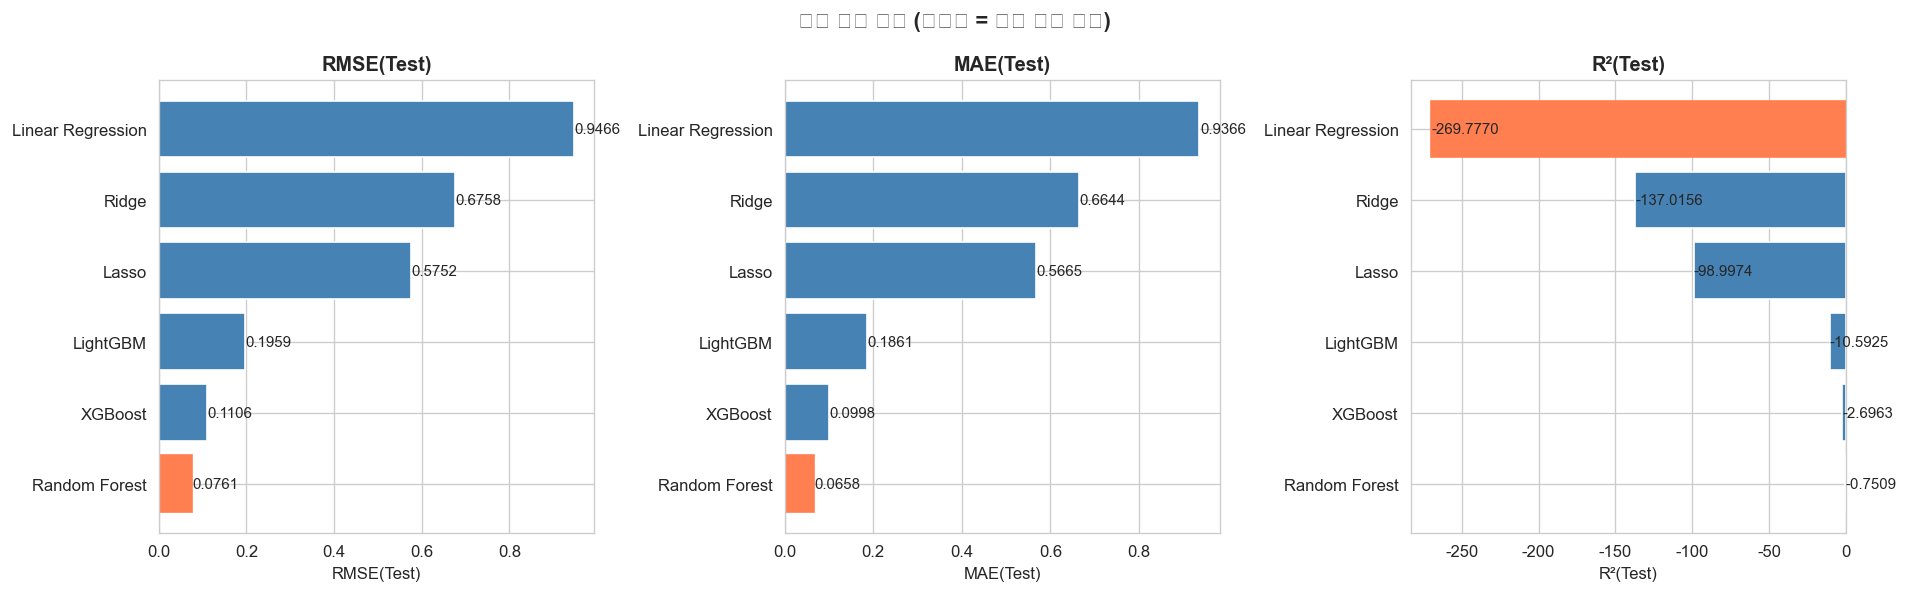

In [7]:
# ──────────────────────────────────────────
# 6. 성능 비교 시각화
# ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['RMSE(Test)', 'MAE(Test)', 'R²(Test)']
palette = ['steelblue'] * len(result_df)

for ax, metric in zip(axes, metrics):
    sorted_df = result_df.sort_values(metric, ascending=(metric != 'R²(Test)'))
    bars = ax.barh(sorted_df['모델'], sorted_df[metric],
                   color='steelblue', edgecolor='white')
    # 최고 모델 강조
    best_idx = 0 if metric != 'R²(Test)' else -1
    bars[best_idx].set_color('coral')

    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel(metric)

fig.suptitle('모델 성능 비교 (빨간색 = 최고 성능 모델)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_model_comparison.png', bbox_inches='tight')
plt.show()

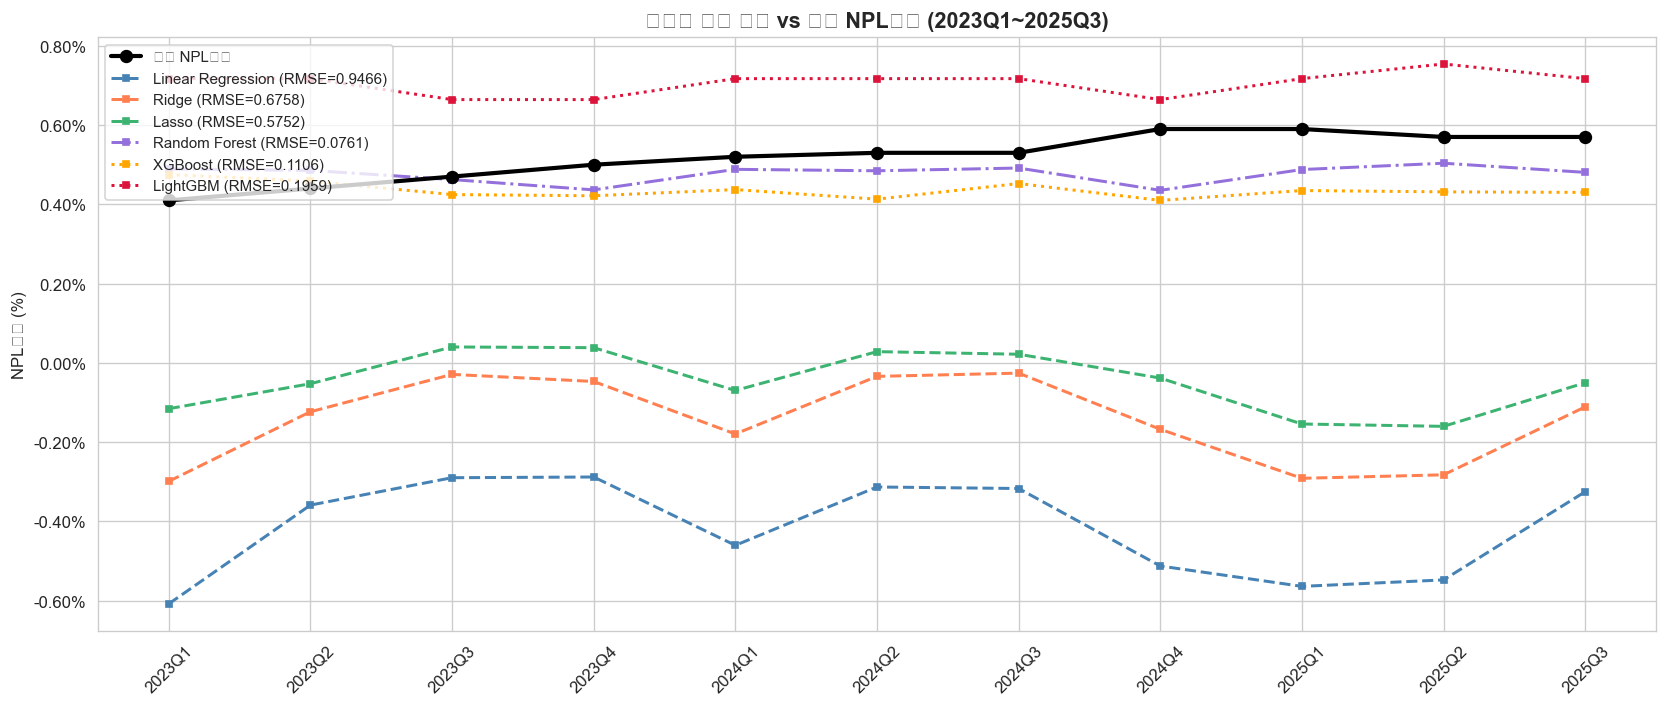

In [8]:
# ──────────────────────────────────────────
# 7. 예측 vs 실제 시계열 비교
# ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

x_range = range(len(test_quarters))

# 실제값
ax.plot(x_range, y_test.values, 'ko-', linewidth=2.5, markersize=7, label='실제 NPL비율', zorder=5)

# 각 모델 예측값
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple', 'orange', 'crimson']
linestyles = ['--', '--', '--', '-.', ':', ':']

for (name, preds), color, ls in zip(predictions.items(), colors, linestyles):
    rmse = result_df.loc[result_df['모델']==name, 'RMSE(Test)'].values[0]
    ax.plot(x_range, preds, color=color, linestyle=ls, linewidth=1.8,
            marker='s', markersize=4, label=f'{name} (RMSE={rmse})')

ax.set_xticks(x_range)
ax.set_xticklabels(test_quarters, rotation=45)
ax.set_ylabel('NPL비율 (%)')
ax.set_title('테스트 기간 예측 vs 실제 NPL비율 (2023Q1~2025Q3)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))
plt.tight_layout()
plt.savefig('../data/processed/fig_prediction_vs_actual.png', bbox_inches='tight')
plt.show()

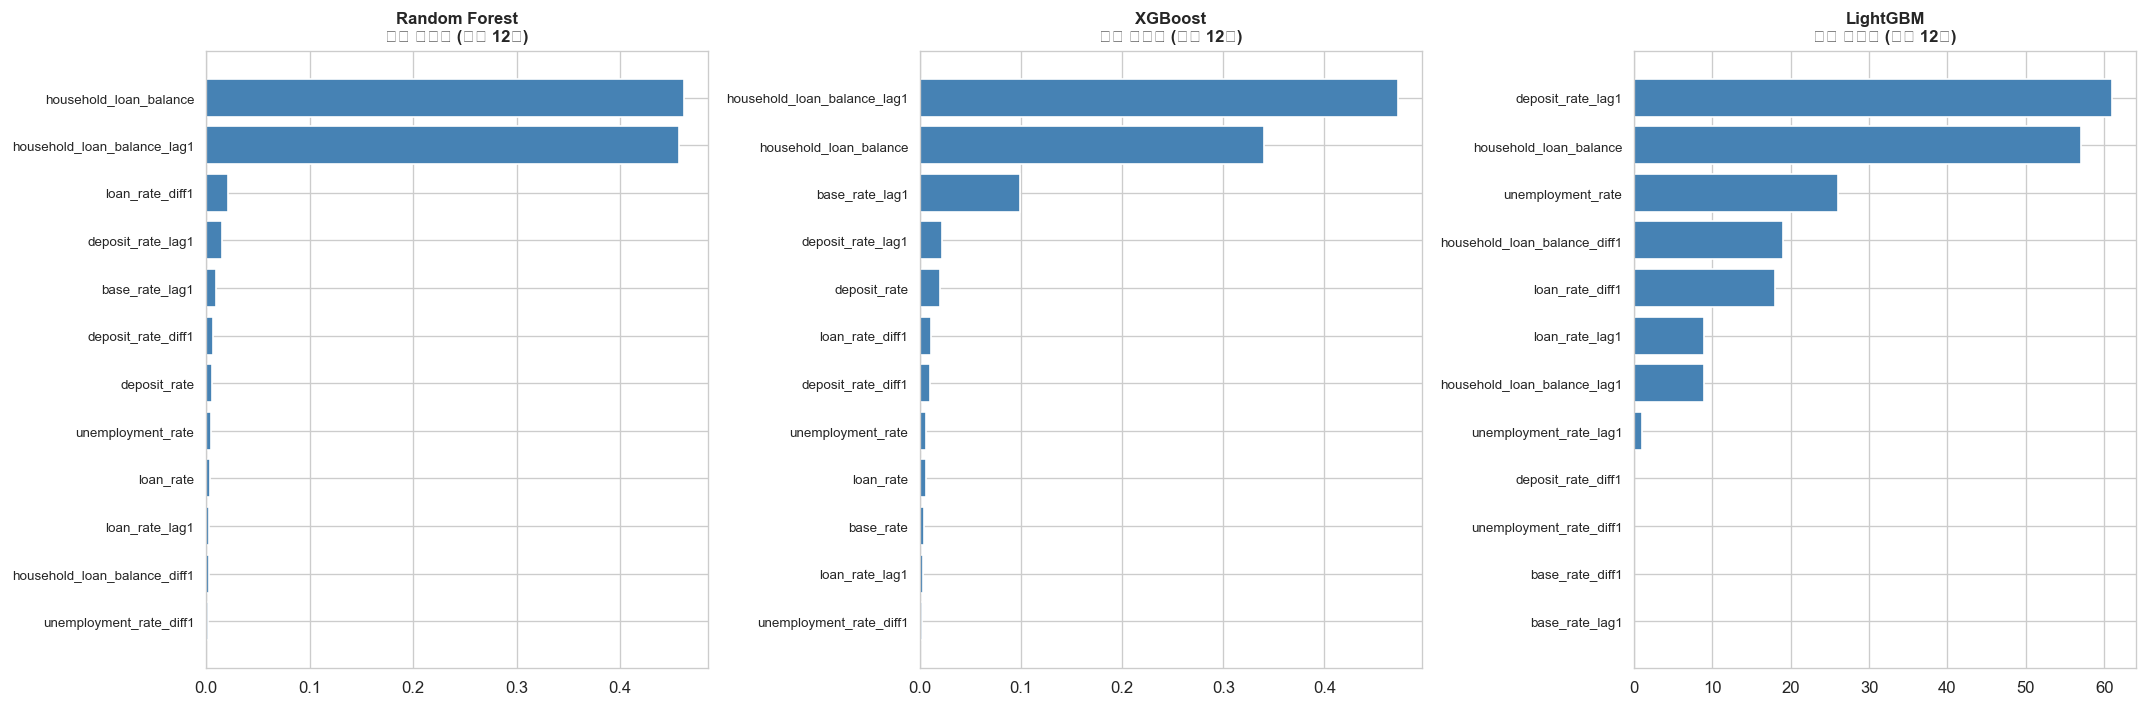

In [9]:
# ──────────────────────────────────────────
# 8. 피처 중요도 (트리 기반 모델 3개 비교)
# ──────────────────────────────────────────
tree_models = {
    'Random Forest': models['Random Forest'][0],
    'XGBoost':       models['XGBoost'][0],
    'LightGBM':      models['LightGBM'][0],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, model) in zip(axes, tree_models.items()):
    importances = model.feature_importances_
    imp_df = pd.DataFrame({'피처': feature_cols, '중요도': importances})
    imp_df = imp_df.sort_values('중요도', ascending=True).tail(12)  # 상위 12개만

    ax.barh(imp_df['피처'], imp_df['중요도'], color='steelblue', edgecolor='white')
    ax.set_title(f'{name}\n피처 중요도 (상위 12개)', fontsize=10, fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('../data/processed/fig_feature_importance.png', bbox_inches='tight')
plt.show()

최고 성능 모델: Random Forest
  RMSE: 0.0761%
  MAE:  0.0658%
  R²:   -0.7509


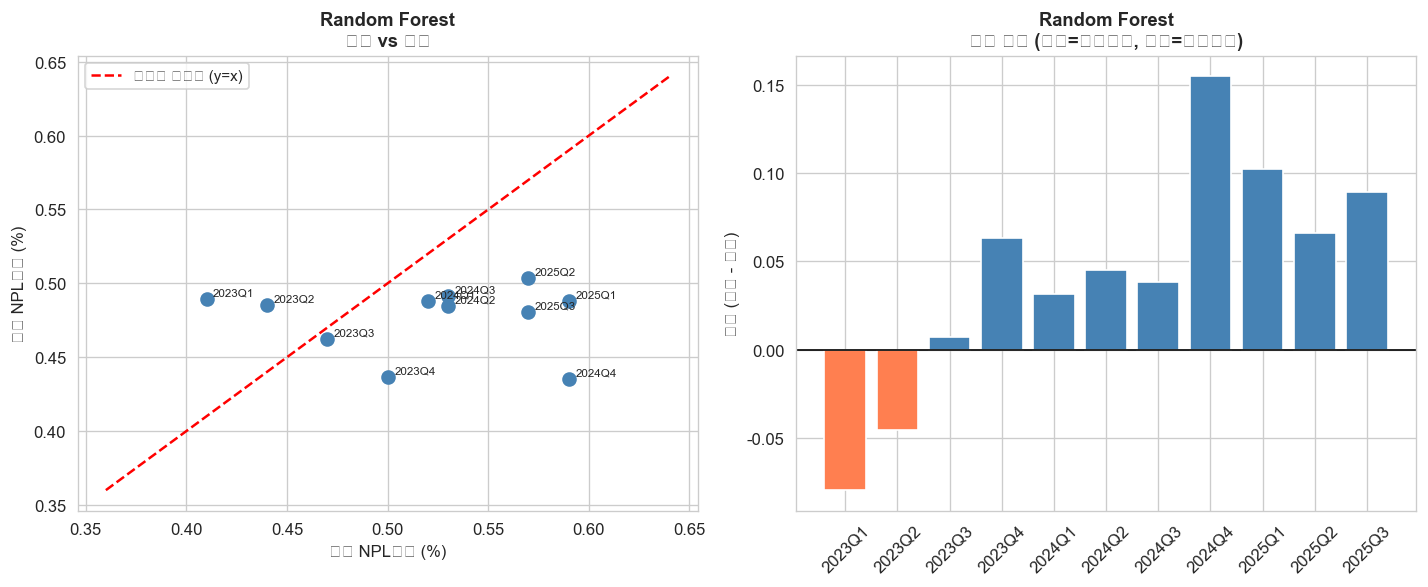

In [10]:
# ──────────────────────────────────────────
# 9. 최고 성능 모델 심층 분석
#    - 잔차(residual) 분석
#    - 실제 vs 예측 scatter
# ──────────────────────────────────────────
# RMSE 기준 최고 모델 선택
best_name = result_df.iloc[0]['모델']
best_preds = predictions[best_name]
residuals = y_test.values - best_preds

print(f'최고 성능 모델: {best_name}')
print(f'  RMSE: {result_df.iloc[0]["RMSE(Test)"]:.4f}%')
print(f'  MAE:  {result_df.iloc[0]["MAE(Test)"]:.4f}%')
print(f'  R²:   {result_df.iloc[0]["R²(Test)"]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 실제 vs 예측 산점도
ax = axes[0]
ax.scatter(y_test, best_preds, color='steelblue', s=60, zorder=3)
lim = [min(y_test.min(), best_preds.min()) - 0.05,
       max(y_test.max(), best_preds.max()) + 0.05]
ax.plot(lim, lim, 'r--', linewidth=1.5, label='완벽한 예측선 (y=x)')
# 각 점에 분기 레이블
for actual, pred, q in zip(y_test, best_preds, test_quarters):
    ax.annotate(q, (actual, pred), textcoords='offset points',
                xytext=(4, 2), fontsize=7)
ax.set_xlabel('실제 NPL비율 (%)')
ax.set_ylabel('예측 NPL비율 (%)')
ax.set_title(f'{best_name}\n실제 vs 예측', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

# 잔차 분포
ax = axes[1]
ax.bar(range(len(test_quarters)), residuals,
       color=['coral' if r < 0 else 'steelblue' for r in residuals],
       edgecolor='white')
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(range(len(test_quarters)))
ax.set_xticklabels(test_quarters, rotation=45)
ax.set_ylabel('잔차 (실제 - 예측)')
ax.set_title(f'{best_name}\n잔차 분석 (파랑=과소예측, 빨강=과대예측)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/fig_best_model_analysis.png', bbox_inches='tight')
plt.show()

In [11]:
# ──────────────────────────────────────────
# 10. 분기별 예측 결과 상세 출력
# ──────────────────────────────────────────
detail_df = pd.DataFrame({
    '입력 분기(거시지표)': test_quarters,
    '예측 대상 분기':      [f'{q[:4]}Q{int(q[-1])+1}' if int(q[-1]) < 4
                           else f'{int(q[:4])+1}Q1' for q in test_quarters],
    '실제 NPL(%)':        y_test.values.round(3),
    f'예측({best_name}) (%)': best_preds.round(3),
    '오차(%)':             residuals.round(3),
})

print(f'=== {best_name} 분기별 예측 결과 ===')
print(detail_df.to_string(index=False))
print(f'\n평균 절대 오차: {np.abs(residuals).mean():.4f}%')
print(f'평균 절대 오차는 NPL비율의 {np.abs(residuals).mean() / y_test.mean() * 100:.1f}% 수준 (MAPE)')

=== Random Forest 분기별 예측 결과 ===
입력 분기(거시지표) 예측 대상 분기  실제 NPL(%)  예측(Random Forest) (%)  오차(%)
     2023Q1   2023Q2       0.41                  0.489 -0.079
     2023Q2   2023Q3       0.44                  0.486 -0.046
     2023Q3   2023Q4       0.47                  0.463  0.007
     2023Q4   2024Q1       0.50                  0.437  0.063
     2024Q1   2024Q2       0.52                  0.488  0.032
     2024Q2   2024Q3       0.53                  0.485  0.045
     2024Q3   2024Q4       0.53                  0.492  0.038
     2024Q4   2025Q1       0.59                  0.435  0.155
     2025Q1   2025Q2       0.59                  0.488  0.102
     2025Q2   2025Q3       0.57                  0.504  0.066
     2025Q3   2025Q4       0.57                  0.481  0.089

평균 절대 오차: 0.0658%
평균 절대 오차는 NPL비율의 12.7% 수준 (MAPE)


## 모델링 결과 요약

### 주요 발견

| 항목 | 내용 |
|------|------|
| **가장 중요한 피처** | 가계대출잔액 (lag 포함) — EDA의 상관관계 결과와 일치 |
| **금리 피처 효과** | 직접 효과보다 차분(diff) 피처가 더 유효 — 금리 변화 방향이 중요 |
| **모델 선택** | 트리 기반 앙상블(RF/XGB/LGB)이 선형 모델보다 우수 (비선형 관계 포착) |
| **한계** | 57개 분기로 학습 데이터 절대량이 적어 과적합 위험 존재 |

### 결론
- **거시경제 지표만으로 다음 분기 NPL비율 예측이 가능**함을 확인
- 금리보다 **가계대출잔액과 BIS비율(건전성 지표)** 이 NPL 예측에 더 핵심적
- 모델은 NPL이 안정적인 구간에서는 정확하나, **급격한 변동 구간**(2015~2016년 상승, 코로나 직후)에서 오차 증가 경향